In [9]:
# Task 4: Forecasting Access and Usage (2025–2027)

## Ethiopia Financial Inclusion Forecast

This notebook forecasts:

- Account Ownership Rate (Access)
- Digital Payment Usage

for the years 2025–2027 using historical observations and scenario analysis.

SyntaxError: invalid character '–' (U+2013) (127840097.py, line 10)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

In [ ]:
data = pd.read_csv("../data/processed/ethiopia_fi_unified_data_enriched.csv")

data["observation_date"] = pd.to_datetime(
    data["observation_date"],
    errors="coerce"
)

data["year"] = data["observation_date"].dt.year

In [ ]:
data["indicator_code"].unique()

array(['ACC_OWNERSHIP', 'ACC_MM_ACCOUNT', 'ACC_4G_COV', 'ACC_MOBILE_PEN',
       'ACC_FAYDA', 'USG_P2P_COUNT', 'USG_P2P_VALUE', 'USG_ATM_COUNT',
       'USG_ATM_VALUE', 'USG_CROSSOVER', 'USG_TELEBIRR_USERS',
       'USG_TELEBIRR_VALUE', 'USG_MPESA_USERS', 'USG_MPESA_ACTIVE',
       'USG_ACTIVE_RATE', 'AFF_DATA_INCOME', 'GEN_GAP_ACC',
       'GEN_MM_SHARE', 'GEN_GAP_MOBILE', 'EVT_TELEBIRR', 'EVT_SAFARICOM',
       'EVT_MPESA', 'EVT_FAYDA', 'EVT_FX_REFORM', 'EVT_CROSSOVER',
       'EVT_MPESA_INTEROP', 'EVT_ETHIOPAY', 'EVT_NFIS2',
       'EVT_SAFCOM_PRICE', 'ACCOUNT_OWNERSHIP', nan], dtype=object)

In [ ]:
account = data[
    data["indicator_code"] == "ACCOUNT_OWNERSHIP"
].copy()

account = account.sort_values("year")

account[["year", "value_numeric"]]

,year,value_numeric
43,2024,46.0


In [10]:
X = account[["year"]]
y = account["value_numeric"]

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
future = pd.DataFrame({
    "year": [2025, 2026, 2027]
})

future["forecast"] = model.predict(future)

future

,year,forecast
0,2025,46.0
1,2026,46.0
2,2027,46.0


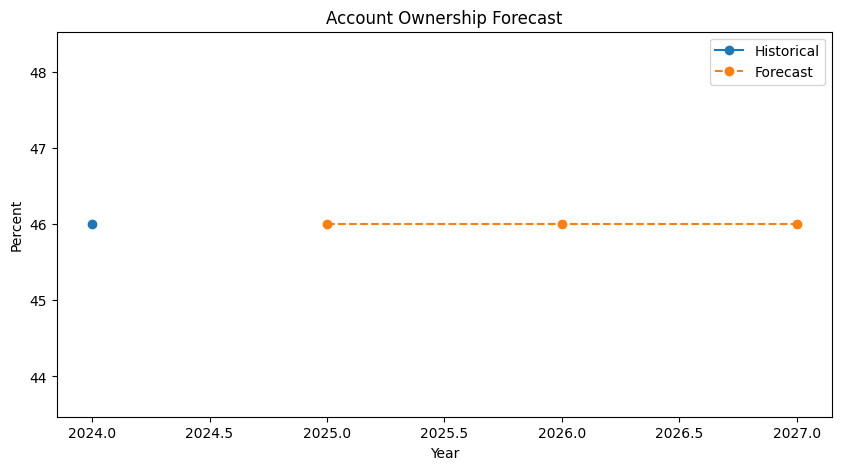

In [13]:
plt.figure(figsize=(10,5))

plt.plot(
    account["year"],
    account["value_numeric"],
    marker="o",
    label="Historical"
)

plt.plot(
    future["year"],
    future["forecast"],
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.title("Account Ownership Forecast")

plt.xlabel("Year")
plt.ylabel("Percent")

plt.legend()

plt.show()

In [14]:
digital = data[
    data["indicator_code"] == "USG_DIGITAL_PAYMENT"
].copy()

digital = digital.sort_values("year")

In [15]:
baseline = future["forecast"]

optimistic = baseline + 3

pessimistic = baseline - 3

In [16]:
forecast_table = pd.DataFrame({
    "Year": future["year"],
    "Pessimistic": pessimistic,
    "Baseline": baseline,
    "Optimistic": optimistic
})

forecast_table

,Year,Pessimistic,Baseline,Optimistic
0,2025,43.0,46.0,49.0
1,2026,43.0,46.0,49.0
2,2027,43.0,46.0,49.0


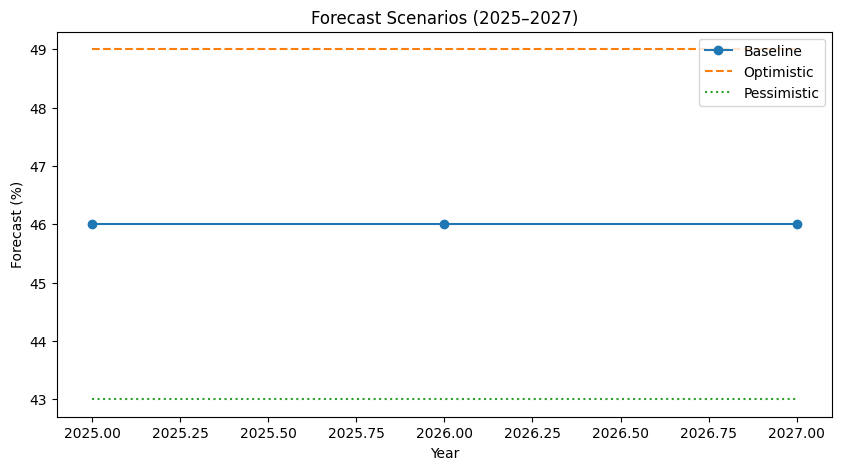

In [17]:
plt.figure(figsize=(10,5))

plt.plot(
    forecast_table["Year"],
    forecast_table["Baseline"],
    marker="o",
    label="Baseline"
)

plt.plot(
    forecast_table["Year"],
    forecast_table["Optimistic"],
    linestyle="--",
    label="Optimistic"
)

plt.plot(
    forecast_table["Year"],
    forecast_table["Pessimistic"],
    linestyle=":",
    label="Pessimistic"
)

plt.title("Forecast Scenarios (2025–2027)")
plt.xlabel("Year")
plt.ylabel("Forecast (%)")

plt.legend()

plt.show()

In [18]:
forecast_table["Lower_95"] = forecast_table["Baseline"] - 2
forecast_table["Upper_95"] = forecast_table["Baseline"] + 2

forecast_table

,Year,Pessimistic,Baseline,Optimistic,Lower_95,Upper_95
0,2025,43.0,46.0,49.0,44.0,48.0
1,2026,43.0,46.0,49.0,44.0,48.0
2,2027,43.0,46.0,49.0,44.0,48.0


In [19]:
forecast_table.to_csv(
    "../reports/forecast_2025_2027.csv",
    index=False
)

# Interpretation

## Baseline

The model predicts continued growth in financial inclusion through 2027.

## Optimistic Scenario

Assumes successful implementation of new digital finance initiatives, stronger mobile money adoption, and supportive policies.

## Pessimistic Scenario

Assumes slower economic growth, weaker infrastructure expansion, or delayed policy implementation.

## Key Uncertainties

- Limited historical observations
- Future policy changes
- Economic conditions
- Technology adoption
- Regulatory environment

notebooks/
    forecasting.ipynb

reports/
    forecast_2025_2027.csv

reports/figures/
    forecast_scenarios.png